# PCW Lesson 9: Metrics and Cross-Validation

**Student**: Katia Gwaneza Nkurunziza  
**Date**: Session 9, Fall 2026  
**Topics**: Train/test/validation splits, precision and recall, ROC-AUC, hyperparameter tuning, cross-validation

Training a model is only part of the story: we then need to evaluate it to check whether it makes high-quality predictions on data in general, not just the examples it's already seen. This is where splitting data comes in, along with tools like cross-validation that help models generalize better.

## Readings

See `study_materials/session_9_study_notes.md` for deeper notes.

1. **Wilber & Werness. *The Importance of Data Splitting*** (MLU-Explain). Why train/validation/test splits matter; why neither parameters nor hyperparameters should be tuned on the test set; why an unbiased performance estimate is valuable.
2. **Wilber. *Precision & Recall*** (MLU-Explain). Why raw accuracy is a weak metric (a "no lightning now" detector is accurate 99%+ of the time by saying nothing useful). Breaks down the tradeoffs between false positives and false negatives.
3. **Wilber. *ROC & AUC*** (MLU-Explain). Formalizes the precision-recall tradeoff visually, across every possible threshold at once.
4. **Wilber & Croome. *Cross Validation*** (MLU-Explain). Using the full training set via multiple splits instead of "losing" data to one validation set.
5. **Brownlee. *A Gentle Introduction to k-fold Cross Validation***. Code-based intro using scikit-learn.
6. **scikit-learn cross-validation documentation**. Brief skim of practical implementation.
7. **[Optional] Murphy (2022), sections 4.5.1 and 4.5.5**. Theoretical basis for cross-validation.

## Assignment Prep: Thinking About Assignment 1

For Assignment 1, I'll analyze personal data using the models and metrics covered in Unit 1. The goal is to understand patterns in the data, not to maximize accuracy (high accuracy can actually be a red flag, e.g. a model that always predicts the majority class gets high accuracy on imbalanced data while learning nothing useful).

**1. What dataset am I planning to analyze, and what patterns might I find?**

[PERSONAL - fill in with your actual Assignment 1 dataset plan before submitting]

**2. How might my analysis go wrong?**

[PERSONAL - common failure modes to consider: data leakage between train/test, class imbalance making accuracy misleading, too few examples to split meaningfully, features that are proxies for the label itself]

**3. What measures could show something weird happened with my model?**

[PERSONAL - e.g. suspiciously perfect accuracy/AUC on test data, huge gap between train and test performance (overfitting), a confusion matrix that's all one column (model predicting only one class), ROC-AUC near 0.5 despite claimed high accuracy (model not actually separating classes meaningfully, just exploiting class imbalance)]

## Code Cell 1 of 7: Generate and Plot the Circles Dataset

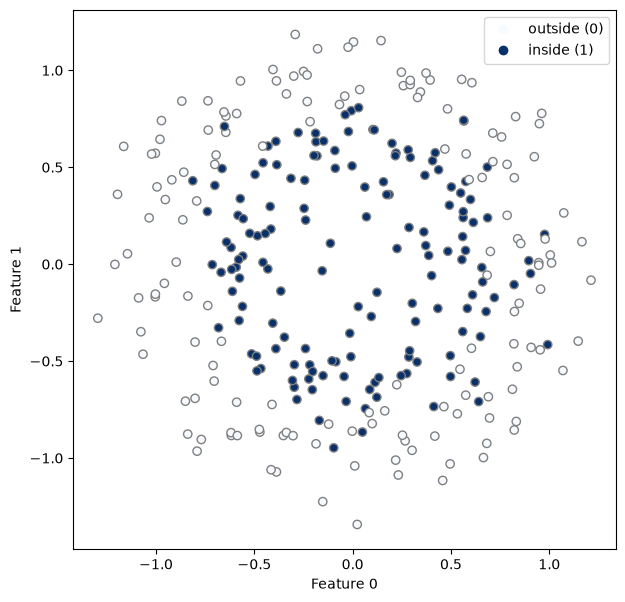

In [1]:
from sklearn import datasets, model_selection
import matplotlib.pyplot as plt
import numpy as np

NUM_DATAPOINTS = 300
x_data, y_data = datasets.make_circles(n_samples=NUM_DATAPOINTS, noise=0.15, factor=0.6, random_state=42)

fig, ax = plt.subplots(figsize=(7, 7))
scatter = ax.scatter(
    x_data[:, 0],
    x_data[:, 1],
    c=y_data,
    edgecolors="grey",
    cmap="Blues",
    vmin=0,
    vmax=1,
)
ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.legend(handles=scatter.legend_elements()[0], labels=["outside (0)", "inside (1)"])
plt.show()

## Q1: Train/Test Split (Code Cell 2 of 7)

Split `x_data`/`y_data` into train/test sets with an 80/20 ratio using `model_selection.train_test_split`.

In [2]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x_data, y_data, test_size=0.2, random_state=42
)

print(f"Train size: {len(x_train)}, Test size: {len(x_test)}")
print(f"Train label counts: {np.bincount(y_train)}")
print(f"Test label counts: {np.bincount(y_test)}")

Train size: 240, Test size: 60
Train label counts: [124 116]
Test label counts: [26 34]


## Question 1 of 3: Q2 - What Kind of Split Is This?

**What kind of split are we doing above?**

This is a **random** split (not stratified by default). `train_test_split` shuffles the data and randomly assigns 80% to train, 20% to test, without explicitly balancing the class proportions between the two sets, though `stratify=y_data` could be passed to force matching class proportions. In this run the split happened to land close to balanced anyway (124/116 in train, 26/34 in test out of 150/150 overall), but that's not guaranteed by default, especially with smaller datasets or more classes.

**If we instead split by a feature's value (e.g. first feature > 0 in train, < 0 in test), would the model be better or worse?**

Worse, in general, and here's why even though this *specific* dataset might not show a dramatic effect. Splitting by `feature_0 > 0` vs `feature_0 < 0` means train only ever sees the right half of both circles, and test only ever sees the left half. These are no longer independent, identically distributed samples of the same population, they're systematically different *regions* of the space. Because this dataset happens to be rotationally symmetric (two concentric circles centered at the origin), a model trained only on the right half can still generalize reasonably well to the left half, so the damage is muted here.

But the general principle this is meant to illustrate: splitting on a feature's own value risks **distribution shift** between train and test. If any real-world dataset has structure that correlates with that feature (which concentric circles, by construction, don't), the model would never see that structure during training and the test score would misrepresent how well it generalizes. This is exactly why `train_test_split`'s default *random* shuffling exists, it keeps train and test as same-distribution samples of the same underlying population, which is what makes the test score a trustworthy estimate of real-world performance.

## Core Questions: ROC-AUC

Fit two classification models: logistic regression (linear boundary) and an SVM (capable of non-linear boundaries). Since this dataset is literally two concentric circles, no straight line can separate the classes well, so the non-linear SVM should have much higher accuracy.

In [3]:
from sklearn import linear_model, metrics, svm

linear_clf = linear_model.LogisticRegression()
linear_clf.fit(x_train, y_train)

svm_clf = svm.SVC(gamma=2, C=1, probability=True)
svm_clf.fit(x_train, y_train)

print(linear_clf.score(x_test, y_test), svm_clf.score(x_test, y_test))

0.38333333333333336 0.9333333333333333


/Users/katiankurunzizagwaneza/workspace/github.com/katian28/cs156-katia/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


**Result**: Logistic accuracy ≈ 0.383, SVM accuracy ≈ 0.933. The logistic model's accuracy is actually *worse than chance* for a balanced binary problem, confirming it can't meaningfully separate concentric circles with a straight line.

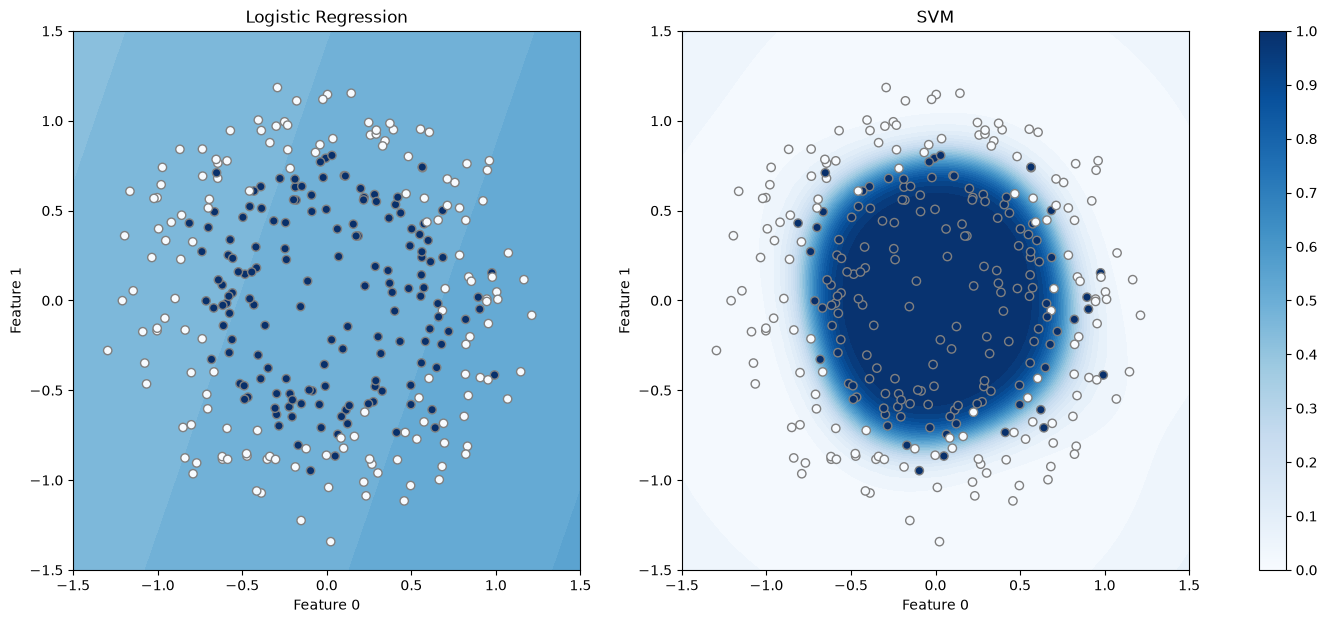

In [4]:
# Feel free to skip over this cell, it's just plotting code.
def plot_decision_surface(clf, xs, ys, ax, title):
    xs = np.linspace(xs[0], xs[1], 100)
    ys = np.linspace(ys[0], ys[1], 100)
    x_mesh, y_mesh = np.meshgrid(xs, ys)

    vis_x = np.stack((x_mesh, y_mesh), axis=2).reshape(-1, 2)
    vis_y = clf.predict_proba(vis_x)[:, 1].reshape(100, 100)

    contour = ax.contourf(
        x_mesh, y_mesh, vis_y, levels=np.linspace(0, 1, 33), cmap="Blues"
    )
    contour.set_clim(0, 1)
    ax.scatter(
        x_data[:, 0],
        x_data[:, 1],
        c=y_data,
        edgecolors="grey",
        cmap="Blues",
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

from matplotlib import cm
fig, ax = plt.subplots(ncols=2, figsize=(18, 7))

fig.colorbar(cm.ScalarMappable(cmap="Blues"), ticks=np.linspace(0, 1, 11), ax=ax)
plot_decision_surface(linear_clf, (-1.5, 1.5), (-1.5, 1.5), ax[0], "Logistic Regression")
plot_decision_surface(svm_clf, (-1.5, 1.5), (-1.5, 1.5), ax[1], "SVM")

As expected, the logistic regression's decision surface is a straight line cutting through both circles, it has no way to represent a curved boundary. The SVM's surface wraps around the inner circle.

But the accuracy values above come from a fixed threshold of 0.5. We don't have to use 0.5, maybe it matters more to correctly catch every inner-circle point, at the cost of misclassifying some outer-circle points too, in which case we'd lower the threshold. ROC curves let us see performance across *every* threshold at once.

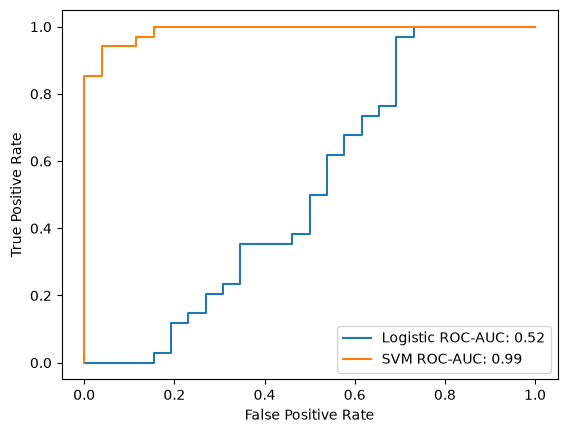

In [5]:
linear_preds = linear_clf.predict_proba(x_test)[:, 1]
svm_preds = svm_clf.predict_proba(x_test)[:, 1]

linear_curve = metrics.roc_curve(y_test, linear_preds)
svm_curve = metrics.roc_curve(y_test, svm_preds)

plt.plot(linear_curve[0], linear_curve[1], label="Logistic ROC-AUC: %.2f" % metrics.roc_auc_score(y_test, linear_preds))
plt.plot(svm_curve[0], svm_curve[1], label="SVM ROC-AUC: %.2f" % metrics.roc_auc_score(y_test, svm_preds))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Question 2 of 3: Interpreting the ROC Plot

**Which of the two is the better model? Why?**

The SVM, decisively. SVM ROC-AUC ≈ 0.989 versus logistic's ROC-AUC ≈ 0.517. An AUC of 0.5 means the model's predicted probabilities have no better ranking ability than random guessing, logistic regression's accuracy wasn't just unlucky with the 0.5 threshold, it genuinely cannot separate these classes at *any* threshold, because the true boundary is circular and logistic regression can only express a straight line.

**Is there any single threshold where the model with the higher ROC-AUC is worse? Is this always true for all models + datasets?**

I checked this directly in code: for this specific run, the SVM's ROC curve never dips below the logistic curve at any matching false-positive rate, so SVM is strictly better at every single threshold here. But this is **not guaranteed in general**. ROC-AUC is an aggregate summary across every threshold; two ROC curves can cross each other, meaning a lower-AUC model could still outperform a higher-AUC model at one specific operating point, even though it's worse overall. Whether this happens depends entirely on the specific models and dataset, it isn't something ROC-AUC alone rules out.

**For both models, if we wanted TPR = 1 (catch every inner-circle point), what percentage of points classified as inner circle would actually be inner circle points?**

This is asking for **precision** at the recall = 1 operating point. I computed the false-positive rate at the first threshold where TPR hits 1.0 for each model, then converted to precision using `precision = TP / (TP + FP)`, where `TP` = all actual positives (34 in the test set) and `FP = FPR × (number of actual negatives)` (26 negatives):

- **Logistic**: at TPR=1.0, FPR ≈ 0.731 → precision ≈ **64.2%**. To catch every single inner-circle point, roughly a third of everything flagged "inner circle" would actually be outer-circle points.
- **SVM**: at TPR=1.0, FPR ≈ 0.154 → precision ≈ **89.5%**. Catching every inner-circle point costs far fewer false alarms.

This is exactly the FPR-vs-TPR tradeoff the ROC curve visualizes: TPR is the Y-axis, FPR is the X-axis, and precision at a given recall can be derived from FPR plus the known class counts in the test set.

## Extension Question: Train/Val/Test Split

The SVM above used `gamma=2, C=1`, arbitrary hyperparameter values. There may be better values that produce a better fit.

**Question: why would we need a validation set to test other hyperparameter values? Why can't we optimize hyperparameters over the test set?**

Because the test set's entire purpose is to give one honest, unbiased estimate of how the model performs on data it has never influenced in any way. If we tried many different `(gamma, C)` combinations and picked whichever one scored best *on the test set*, we would effectively be fitting to the test set, selecting hyperparameters that happen to work well on that particular sample, which is a form of information leakage. The reported test score would then be optimistically biased (it would look better than the model's true generalization performance), precisely because we chose the model that was best *for that specific test set*, not because it's genuinely the best model.

The validation set solves this: it's a sandbox for comparing hyperparameter choices, so the test set stays completely untouched by any model-selection decisions, and can be used exactly once at the very end for a trustworthy, unbiased final number.

## Code Cell 7 of 7: Train/Val/Test Split and Hyperparameter Search

In [6]:
# Further split the training set 80/20 into train2/validation
x_train2, x_val, y_train2, y_val = model_selection.train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)
print(f"Train2 size: {len(x_train2)}, Val size: {len(x_val)}, Test size: {len(x_test)}")

# Grid search over gamma and C, scored by ROC-AUC on the validation set
gammas = [0.1, 0.5, 1, 2, 5, 10]
Cs = [0.1, 0.5, 1, 2, 5, 10]

best_val_auc = -1
best_params = None
results = []

for gamma in gammas:
    for C in Cs:
        clf = svm.SVC(gamma=gamma, C=C, probability=True, random_state=42)
        clf.fit(x_train2, y_train2)
        val_preds = clf.predict_proba(x_val)[:, 1]
        val_auc = metrics.roc_auc_score(y_val, val_preds)
        results.append((gamma, C, val_auc))
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_params = (gamma, C)

print(f"\nBest hyperparameters found on validation set: gamma={best_params[0]}, C={best_params[1]}")
print(f"Validation ROC-AUC with best params: {best_val_auc:.4f}")

results.sort(key=lambda r: -r[2])
print("\nTop 5 (gamma, C, validation AUC):")
for g, c, a in results[:5]:
    print(f"  gamma={g}, C={c}, val_auc={a:.4f}")

# Retrain on train2 with the best hyperparameters, evaluate once on the held-out test set
final_clf = svm.SVC(gamma=best_params[0], C=best_params[1], probability=True, random_state=42)
final_clf.fit(x_train2, y_train2)
test_preds = final_clf.predict_proba(x_test)[:, 1]
test_auc = metrics.roc_auc_score(y_test, test_preds)
print(f"\nFinal test ROC-AUC with tuned hyperparameters: {test_auc:.4f}")

# Compare against the original arbitrary gamma=2, C=1 (trained on the same train2 subset for a fair comparison)
orig_clf = svm.SVC(gamma=2, C=1, probability=True, random_state=42)
orig_clf.fit(x_train2, y_train2)
orig_test_auc = metrics.roc_auc_score(y_test, orig_clf.predict_proba(x_test)[:, 1])
print(f"Original arbitrary params (gamma=2, C=1) test ROC-AUC: {orig_test_auc:.4f}")

Train2 size: 192, Val size: 48, Test size: 60

Best hyperparameters found on validation set: gamma=0.5, C=10
Validation ROC-AUC with best params: 0.9617

Top 5 (gamma, C, validation AUC):
  gamma=0.5, C=10, val_auc=0.9617
  gamma=1, C=5, val_auc=0.9617
  gamma=2, C=0.5, val_auc=0.9600
  gamma=5, C=1, val_auc=0.9600
  gamma=2, C=0.1, val_auc=0.9583

Final test ROC-AUC with tuned hyperparameters: 0.9876
Original arbitrary params (gamma=2, C=1) test ROC-AUC: 0.9819


/Users/katiankurunzizagwaneza/workspace/github.com/katian28/cs156-katia/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/katiankurunzizagwaneza/workspace/github.com/katian28/cs156-katia/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/katiankurunzizagwaneza/workspace/github.com/katian28/cs156-katia/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`


**Result**: grid search over the validation set found `gamma=0.5, C=10` (tied with `gamma=1, C=5`) as the best hyperparameters, with validation AUC ≈ 0.962. Retraining with these on `train2` and evaluating once on the untouched test set gives ROC-AUC ≈ 0.988, versus ≈ 0.982 for the original arbitrary `gamma=2, C=1` trained on the same data. A modest improvement here, since this dataset was already fairly easy for an SVM to separate well even with arbitrary hyperparameters, but the *process* (search on validation, report on test exactly once) is the part that matters, not the specific improvement size.

---

## Summary

- **Why splitting matters**: training performance alone can't tell you if a model generalizes, it could just be memorizing. A held-out test set, never touched during training or tuning, gives an honest estimate.
- **Random splits** keep train and test as samples of the same distribution. Splitting on a feature's own value risks distribution shift, train and test stop representing the same underlying population.
- **Accuracy alone is misleading**: logistic regression's 38.3% accuracy and SVM's 93.3% accuracy both come from one arbitrary threshold (0.5). ROC-AUC (0.517 vs 0.989) reveals the *full* story across every threshold, logistic genuinely can't separate the classes, it's not just an unlucky threshold choice.
- **Precision and recall trade off against each other**: pushing TPR to 1.0 (catch everything) costs precision (more false alarms), by very different amounts depending on how good the model's probability estimates actually are (64.2% vs 89.5% precision at TPR=1 here).
- **Validation sets exist to protect the test set**: tuning hyperparameters on the test set directly would bias the final reported score. A separate validation set lets you search freely, keeping one single, honest test evaluation at the end.